In [1]:
import torch
from torch import nn

In [2]:
w=0.7
b=0.3
x=torch.arange(0,1,0.02).unsqueeze(dim=1)
y=b+w*x

In [3]:
import seaborn as sns
from sklearn.model_selection import train_test_split as tts

<Axes: >

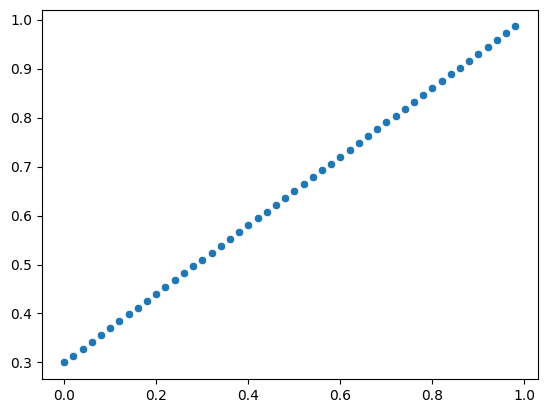

In [4]:
sns.scatterplot(x=x.squeeze().numpy(),y=y.squeeze().numpy())

In [5]:
x.shape,y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [6]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=18)

<Axes: >

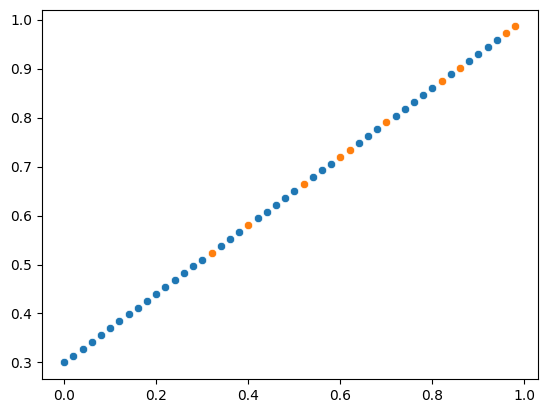

In [7]:
sns.scatterplot(x=x_train.squeeze().numpy(),y=y_train.squeeze().numpy())
sns.scatterplot(x=x_test.squeeze().numpy(),y=y_test.squeeze().numpy())

In [8]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        self.bias=nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
    def forward(self,x):
        return x*self.weights+self.bias

In [9]:
torch.manual_seed(18)
model=LinearRegression()
list(model.parameters())

[Parameter containing:
 tensor([0.5941], requires_grad=True),
 Parameter containing:
 tensor([-0.1271], requires_grad=True)]

In [10]:
model.state_dict()

OrderedDict([('weights', tensor([0.5941])), ('bias', tensor([-0.1271]))])

In [11]:
with torch.inference_mode():
    y_pred=model(x_test)
y_pred

tensor([[0.3838],
        [0.0630],
        [0.1818],
        [0.2293],
        [0.1105],
        [0.4551],
        [0.2412],
        [0.4432],
        [0.2887],
        [0.3600]])

In [12]:
y_test

tensor([[0.9020],
        [0.5240],
        [0.6640],
        [0.7200],
        [0.5800],
        [0.9860],
        [0.7340],
        [0.9720],
        [0.7900],
        [0.8740]])

In [13]:
loss_func=nn.L1Loss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)

In [14]:
torch.manual_seed(18)
epochs=10000
for epoch in range(epochs):
    y_pred=model(x_train)
    loss=loss_func(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [15]:
model.state_dict()

OrderedDict([('weights', tensor([0.7038])), ('bias', tensor([0.2939]))])

In [18]:
w,b

(0.7, 0.3)

In [20]:
model.eval()
with torch.inference_mode():
    y_test_pred=model(x_test)
    loss=loss_func(y_test_pred,y_test)

In [21]:
print(loss)

tensor(0.0035)


In [22]:
from sklearn.metrics import r2_score as r2

In [25]:
print(r2(y_test,y_test_pred))

0.999424159526825


In [26]:
torch.save(model.state_dict(),"Linear_Regression_Model.pth")

In [27]:
loaded_model=LinearRegression()
loaded_model.state_dict()

OrderedDict([('weights', tensor([0.5941])), ('bias', tensor([-0.1271]))])

In [28]:
loaded_model.load_state_dict(torch.load("Linear_Regression_Model.pth"))

<All keys matched successfully>

In [29]:
loaded_model.state_dict()

OrderedDict([('weights', tensor([0.7038])), ('bias', tensor([0.2939]))])